<a href="https://colab.research.google.com/github/AaronBraz/fonte-de-informa-o-e-banco-de-dados/blob/main/sorvete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("raphaelmanayon/temperature-and-ice-cream-sales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'temperature-and-ice-cream-sales' dataset.
Path to dataset files: /kaggle/input/temperature-and-ice-cream-sales


In [9]:
import os
import glob
import pandas as pd

# List files in the dataset directory
files_in_path = os.listdir(path)
print("Files in dataset directory:", files_in_path)

# Assuming there's a single CSV file, find it and load it
csv_files = glob.glob(os.path.join(path, '*.csv'))

if csv_files:
    data_file_path = csv_files[0]
    print(f"Loading data from: {data_file_path}")
    df = pd.read_csv(data_file_path)
    print("Dataset loaded successfully.")
    display(df.head(10))
else:
    print("No CSV files found in the dataset directory.")

Files in dataset directory: ['Ice Cream Sales - temperatures.csv']
Loading data from: /kaggle/input/temperature-and-ice-cream-sales/Ice Cream Sales - temperatures.csv
Dataset loaded successfully.


,Temperature,Ice Cream Profits
0,39,13.17
1,40,11.88
2,41,18.82
3,42,18.65
4,43,17.02
5,43,15.88
6,44,19.07
7,44,19.57
8,45,21.62
9,45,22.34


Data split into training and testing sets:
  Training samples: 292
  Testing samples: 73

Linear Regression model trained.
  Intercept: -33.66
  Coefficient (Temperature): 1.19

Model Evaluation:
  Mean Absolute Error (MAE): 1.85
  Mean Squared Error (MSE): 5.29
  R-squared (R2): 0.98


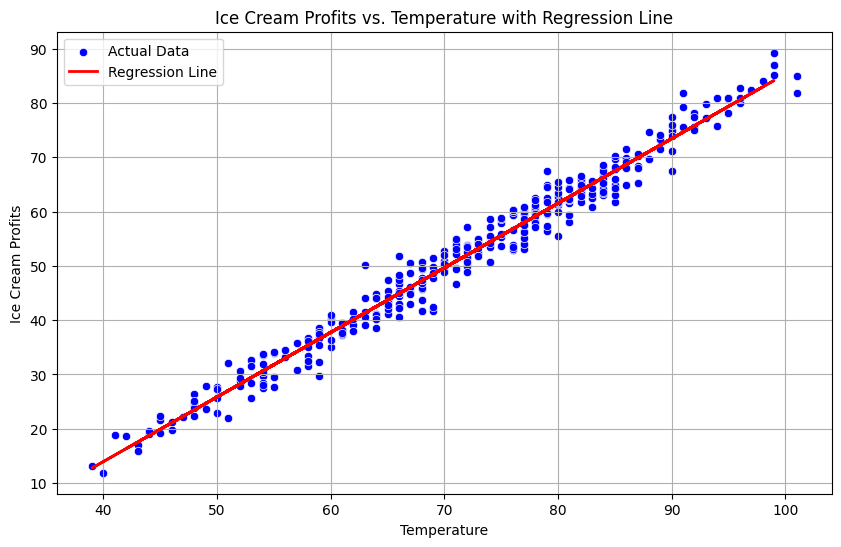

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define independent (X) and dependent (y) variables
X = df[['Temperature']]
y = df['Ice Cream Profits']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets:")
print(f"  Training samples: {len(X_train)}")
print(f"  Testing samples: {len(X_test)}")

# Create a Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("\nLinear Regression model trained.")
print(f"  Intercept: {model.intercept_:.2f}")
print(f"  Coefficient (Temperature): {model.coef_[0]:.2f}")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print(f"  Mean Absolute Error (MAE): {mae:.2f}")
print(f"  Mean Squared Error (MSE): {mse:.2f}")
print(f"  R-squared (R2): {r2:.2f}")

# Plotting the regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X['Temperature'], y=y, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Ice Cream Profits vs. Temperature with Regression Line')
plt.xlabel('Temperature')
plt.ylabel('Ice Cream Profits')
plt.legend()
plt.grid(True)
plt.show()